# Are inversions in repeat regions?
Now that we did some repeat modeling and classification, we can see if the breakpoints of any of the simulated inversions fall into these identified repeat regions.

In [49]:
library(dplyr)
library(ggplot2)
library(ggh4x)
library(tidyr)

## Read in the repeat data

In [50]:
repeats <- read.table("repeat.regions", header = T)
repeats <- arrange(repeats[order(repeats$contig), ], contig, position_start)
# overwrite the file with it being sorted by chrom + start position
#write.table(repeats, file = "repeat.regions", quote = F, row.names = F)
nrow(repeats)
head(repeats, 15)

[1] 5157

,contig,position_start,position_end,class
,<chr>,<int>,<int>,<chr>
1,2L,65701,65763,Interspersed_Repeat;Unknown
2,2L,687402,688026,Interspersed_Repeat;Transposable_Element;Class_I_Retrotransposition;Retrotransposon;Long_Terminal_Repeat_Element;Bel-Pao
3,2L,687966,693711,Interspersed_Repeat;Transposable_Element;Class_I_Retrotransposition;Retrotransposon;Long_Terminal_Repeat_Element;Bel-Pao
4,2L,693689,695243,Interspersed_Repeat;Transposable_Element;Class_I_Retrotransposition;Retrotransposon;Long_Terminal_Repeat_Element;Bel-Pao
5,2L,695117,695527,Interspersed_Repeat;Transposable_Element;Class_I_Retrotransposition;Retrotransposon;Long_Terminal_Repeat_Element;Bel-Pao
6,2L,977363,979264,Interspersed_Repeat;Transposable_Element;Class_I_Retrotransposition;Retrotransposon;Long_Terminal_Repeat_Element;Bel-Pao
7,2L,979242,983449,Interspersed_Repeat;Transposable_Element;Class_I_Retrotransposition;Retrotransposon;Long_Terminal_Repeat_Element;Bel-Pao
8,2L,983448,983532,Interspersed_Repeat;Transposable_Element;Class_I_Retrotransposition;Retrotransposon;Long_Terminal_Repeat_Element;Bel-Pao
9,2L,983472,984084,Interspersed_Repeat;Transposable_Element;Class_I_Retrotransposition;Retrotransposon;Long_Terminal_Repeat_Element;Bel-Pao


## Read in inversion inventory
We'll to read in the inventory of all inversion positions and pull out the unique inversions. I really should have committed to either comma or tab separated tables.

In [52]:
inversions <- read.csv("../assess_sv_leviathan/visor/linkedread.sv.assessment", header = T)
inversions <- unique(inversions[, c(1,6,9,10)])
rownames(inversions) <- NULL
inversions$is_repeat <- as.character(NA)
inversions$which_breakpoints <- 0
inversions$is_repeat_start <- as.character(NA)
inversions$is_repeat_end <- as.character(NA)
head(inversions)

,contig,size,position_start,position_end,is_repeat,which_breakpoints,is_repeat_start,is_repeat_end
,<chr>,<chr>,<int>,<int>,<chr>,<dbl>,<chr>,<chr>
1,2L,small,3193196,3214221,NA,0,NA,NA
2,2L,small,3940211,3944863,NA,0,NA,NA
3,2L,small,13024404,13026577,NA,0,NA,NA
4,2L,small,14845709,14861200,NA,0,NA,NA
5,2L,small,20107901,20113695,NA,0,NA,NA
6,2R,small,4328632,4333509,NA,0,NA,NA


## Assess which inversions are in or adjacent to repeat regions
To do the matchy-matchy, similar to what we did to assess inversion calling. It will need some modifications to accommodate the slightly different use case. Primarily, adding a `800bp` buffer to the repeat breakpoints to catch inversion breakpoints that might be within an insert-size of the repeat breakpoint. The `which_breakpoints` column codes either `0` for "none", `1` for first-only, `2` for second-only, and `3` for both.

In [53]:
for(i in 1:nrow(inversions)){
    .row <- inversions[i,]
    # first breakpoint
    query <- which(
        repeats$contig == .row$contig &
        (repeats$position_start - 800 <= .row$position_start & repeats$position_end + 800 >= .row$position_start)
    )
    if(length(query) > 0) {
        inversions$is_repeat_start[i] <- paste(repeats$class[query], collapse = ";")
        inversions$which_breakpoints[i] <- inversions$which_breakpoints[i] + 1  
    }
    # second breakpoint
    query <- which(
        repeats$contig == .row$contig &
        (repeats$position_start - 800 <= .row$position_end) & (repeats$position_end + 800 >= .row$position_end)
    )
    if(length(query) > 0) {
        inversions$is_repeat_end[i] <- paste(repeats$class[query], collapse = ";")
        inversions$which_breakpoints[i] <- inversions$which_breakpoints[i] + 2
    }
}
inversions$is_repeat <- !is.na(inversions$is_repeat_start) | !is.na(inversions$is_repeat_end)
are_repeats <- inversions[inversions$is_repeat, ]
are_repeats

,contig,size,position_start,position_end,is_repeat,which_breakpoints,is_repeat_start,is_repeat_end
,<chr>,<chr>,<int>,<int>,<lgl>,<dbl>,<chr>,<chr>
5,2L,small,20107901,20113695,TRUE,2,NA,Interspersed_Repeat;Transposable_Element;Class_II_DNA_Transposition;Transposase;Tc1-Mariner;Tc1;Interspersed_Repeat;Transposable_Element;Class_II_DNA_Transposition;Transposase;Tc1-Mariner;Tc1;Interspersed_Repeat;Transposable_Element;Class_II_DNA_Transposition;Transposase;CACTA;Transib
6,2R,small,4328632,4333509,TRUE,3,Interspersed_Repeat;Transposable_Element;Class_I_Retrotransposition;Retrotransposon;Long_Terminal_Repeat_Element;Bel-Pao,Interspersed_Repeat;Transposable_Element;Class_I_Retrotransposition;LINE;Group-II;Group-2;R1-like;R1-group;I-group;Jockey
15,3L,small,26678791,26687230,TRUE,1,Interspersed_Repeat;Transposable_Element;Class_I_Retrotransposition;LINE;Group-II;Group-2;R1-like;R1-group;I-group;Jockey,NA
19,3R,small,24971985,24984761,TRUE,2,NA,Interspersed_Repeat;Transposable_Element;Class_I_Retrotransposition;Retrotransposon;Long_Terminal_Repeat_Element;Gypsy-ERV;Gypsy;Interspersed_Repeat;Transposable_Element;Class_I_Retrotransposition;Retrotransposon;Long_Terminal_Repeat_Element;Gypsy-ERV;Gypsy
33,3R,medium,16760480,16905871,TRUE,1,Interspersed_Repeat;Transposable_Element;Class_I_Retrotransposition;Retrotransposon;Long_Terminal_Repeat_Element;Bel-Pao,NA
39,2R,large,1439997,4186470,TRUE,3,Interspersed_Repeat;Transposable_Element;Class_I_Retrotransposition;LINE;Group-II;Group-2;R1-like;R1-group;I-group;Jockey,Interspersed_Repeat;Unknown


## Read in inversion results
Let's find which inversions had the most false negatives.

In [54]:
false_neg <- read.csv("../assess_sv_leviathan/visor/linkedread.sv.assessment", header = T) %>%
    group_by(contig, position_start, position_end, size) %>%
    mutate(perc = round(sum(assessment == "false negative")/length(depth) * 100,1)) %>%
    filter(assessment == "false negative") %>%
    summarize(n = length(depth), perc = unique(perc)) %>%
    ungroup() %>%
    arrange(desc(n))

false_neg$is_repeat <- FALSE
false_neg$which_breakpoint <- as.integer(0)
head(false_neg)

`summarise()` has grouped output by 'contig', 'position_start', 'position_end'.
You can override using the `.groups` argument.


contig,position_start,position_end,size,n,perc,is_repeat,which_breakpoint
<chr>,<int>,<int>,<chr>,<int>,<dbl>,<lgl>,<int>
2L,1591146,1776073,medium,55,100.0,FALSE,0
2L,6436329,6636405,medium,55,100.0,FALSE,0
2R,4328632,4333509,small,55,100.0,FALSE,0
3R,16760480,16905871,medium,40,72.7,FALSE,0
3R,26216293,26389606,medium,30,54.5,FALSE,0
2R,15862083,16302028,medium,26,47.3,FALSE,0


We can now combine the inversions-in-repeats with the inversions-not-detected dataframe to see if there's a correlation of hard-to-call inversions being associated with repeat regions.

In [55]:
for(i in 1:nrow(false_neg)){
    .row <- false_neg[i,]
    query <- which(
        are_repeats$contig == .row$contig &
        are_repeats$position_start == .row$position_start
    )
    if(length(query) > 0) {
        false_neg$is_repeat[i] <- TRUE
        false_neg$which_breakpoint[i] <- are_repeats$which_breakpoint[query]
    }
}
false_neg$platform <- "linkedread"
head(arrange(false_neg, desc(is_repeat)))

contig,position_start,position_end,size,n,perc,is_repeat,which_breakpoint,platform
<chr>,<int>,<int>,<chr>,<int>,<dbl>,<lgl>,<dbl>,<chr>
2R,4328632,4333509,small,55,100.0,TRUE,3,linkedread
3R,16760480,16905871,medium,40,72.7,TRUE,1,linkedread
2L,20107901,20113695,small,23,41.8,TRUE,2,linkedread
2R,1439997,4186470,large,22,40.0,TRUE,3,linkedread
3L,26678791,26687230,small,20,36.4,TRUE,1,linkedread
3R,24971985,24984761,small,9,16.4,TRUE,2,linkedread


For comparison sake, we need to do this with the long-read inversion detections as well. We'll read it in and extract only the relevant columns and only rows where `assessment` is `false negative`.

In [61]:
long_inv <- read.csv("../longread_workflow/longread.sv.assessment", header = T)
false_neg_long <- group_by(long_inv[,c(2:5, 8,10)], contig, position_start, position_end, size, platform) %>%
    mutate(perc = round(sum(assessment == "false negative")/length(assessment) * 100,1)) %>%
    filter(assessment == "false negative") %>%
    summarize(n = length(assessment), perc = unique(perc)) %>%
    ungroup() %>%
    arrange(desc(n))
false_neg_long$is_repeat <- FALSE
false_neg_long$which_breakpoint <- as.integer(0)

head(false_neg_long, 20)

`summarise()` has grouped output by 'contig', 'position_start', 'position_end',
'size'. You can override using the `.groups` argument.


contig,position_start,position_end,size,platform,n,perc,is_repeat,which_breakpoint
<chr>,<int>,<int>,<chr>,<chr>,<int>,<dbl>,<lgl>,<int>
2R,4328632,4333509,small,ontshort,32,64,FALSE,0
2R,1439997,4186470,large,ontlong,23,46,FALSE,0
2R,4328632,4333509,small,ontlong,23,46,FALSE,0
3R,16760480,16905871,medium,ontshort,22,44,FALSE,0
2R,4328632,4333509,small,pacbio,20,40,FALSE,0
2R,1439997,4186470,large,ontshort,17,34,FALSE,0
2R,9952840,9959287,small,ontlong,17,34,FALSE,0
2R,1439997,4186470,large,pacbio,16,32,FALSE,0
2R,10569437,10578078,small,ontlong,16,32,FALSE,0


Now do the same matching between inversions and repeat regions

In [62]:
for(i in 1:nrow(false_neg_long)){
    .row <- false_neg_long[i,]
    query <- which(
        are_repeats$contig == .row$contig &
        are_repeats$position_start == .row$position_start
    )
    if(length(query) > 0) {
        false_neg_long$is_repeat[i] <- TRUE
        false_neg_long$which_breakpoint[i] <- are_repeats$which_breakpoint[query]
    }
}
head(arrange(false_neg_long, desc(is_repeat)))

contig,position_start,position_end,size,platform,n,perc,is_repeat,which_breakpoint
<chr>,<int>,<int>,<chr>,<chr>,<int>,<dbl>,<lgl>,<dbl>
2R,4328632,4333509,small,ontshort,32,64,TRUE,3
2R,1439997,4186470,large,ontlong,23,46,TRUE,3
2R,4328632,4333509,small,ontlong,23,46,TRUE,3
3R,16760480,16905871,medium,ontshort,22,44,TRUE,1
2R,4328632,4333509,small,pacbio,20,40,TRUE,3
2R,1439997,4186470,large,ontshort,17,34,TRUE,3


Let's combine the two dataframes so we can start plotting them to meaningfully represent these data. This will also include making `platform`, `size`, and `contig` ordered factors.

In [63]:
false_neg_all <- rbind(false_neg, false_neg_long) %>% arrange(desc(n), desc(platform), desc(size))
false_neg_all$contig <- factor(false_neg_all$contig, levels = c("2L", "2R","3L","3R"), ordered = T)
false_neg_all$size <- factor(false_neg_all$size, levels = c("small", "medium", "large", "xl"))
false_neg_all$platform <- factor(false_neg_all$platform, levels = c("linkedread","ontshort","ontlong","pacbio"))

head(false_neg_all)

contig,position_start,position_end,size,n,perc,is_repeat,which_breakpoint,platform
<ord>,<int>,<int>,<fct>,<int>,<dbl>,<lgl>,<dbl>,<fct>
2R,4328632,4333509,small,55,100.0,TRUE,3,linkedread
2L,1591146,1776073,medium,55,100.0,FALSE,0,linkedread
2L,6436329,6636405,medium,55,100.0,FALSE,0,linkedread
3R,16760480,16905871,medium,40,72.7,TRUE,1,linkedread
2R,4328632,4333509,small,32,64.0,TRUE,3,ontshort
3R,26216293,26389606,medium,30,54.5,FALSE,0,linkedread


It may be worth adding a column of unique identifiers for the inversions for plotting purposes.

In [64]:
false_neg_all <- group_by(false_neg_all, is_repeat,position_start) %>%
    mutate(inv_id = cur_group_id())
false_neg_all$seq_id <- 1:nrow(false_neg_all)
head(false_neg_all, 15)

contig,position_start,position_end,size,n,perc,is_repeat,which_breakpoint,platform,inv_id,seq_id
<ord>,<int>,<int>,<fct>,<int>,<dbl>,<lgl>,<dbl>,<fct>,<int>,<int>
2R,4328632,4333509,small,55,100.0,TRUE,3,linkedread,44,1
2L,1591146,1776073,medium,55,100.0,FALSE,0,linkedread,3,2
2L,6436329,6636405,medium,55,100.0,FALSE,0,linkedread,11,3
3R,16760480,16905871,medium,40,72.7,TRUE,1,linkedread,45,4
2R,4328632,4333509,small,32,64.0,TRUE,3,ontshort,44,5
3R,26216293,26389606,medium,30,54.5,FALSE,0,linkedread,42,6
2R,15862083,16302028,medium,26,47.3,FALSE,0,linkedread,22,7
2R,18236490,18696638,medium,26,47.3,FALSE,0,linkedread,27,8
2L,961650,21551190,xl,24,43.6,FALSE,0,linkedread,2,9


## Visualization

In [65]:
tech_colors <- c(
    "ontshort" = "#9b6981",
    "ontlong" = "#682c37",
    "pacbio" = "#f6955e" ,
    "linkedread" = "#a8cdec"
)

size_colors <- c(
    "#c0c6cf",
    "#a2aab5",
    "#6e7684",
    "#54546c"
)

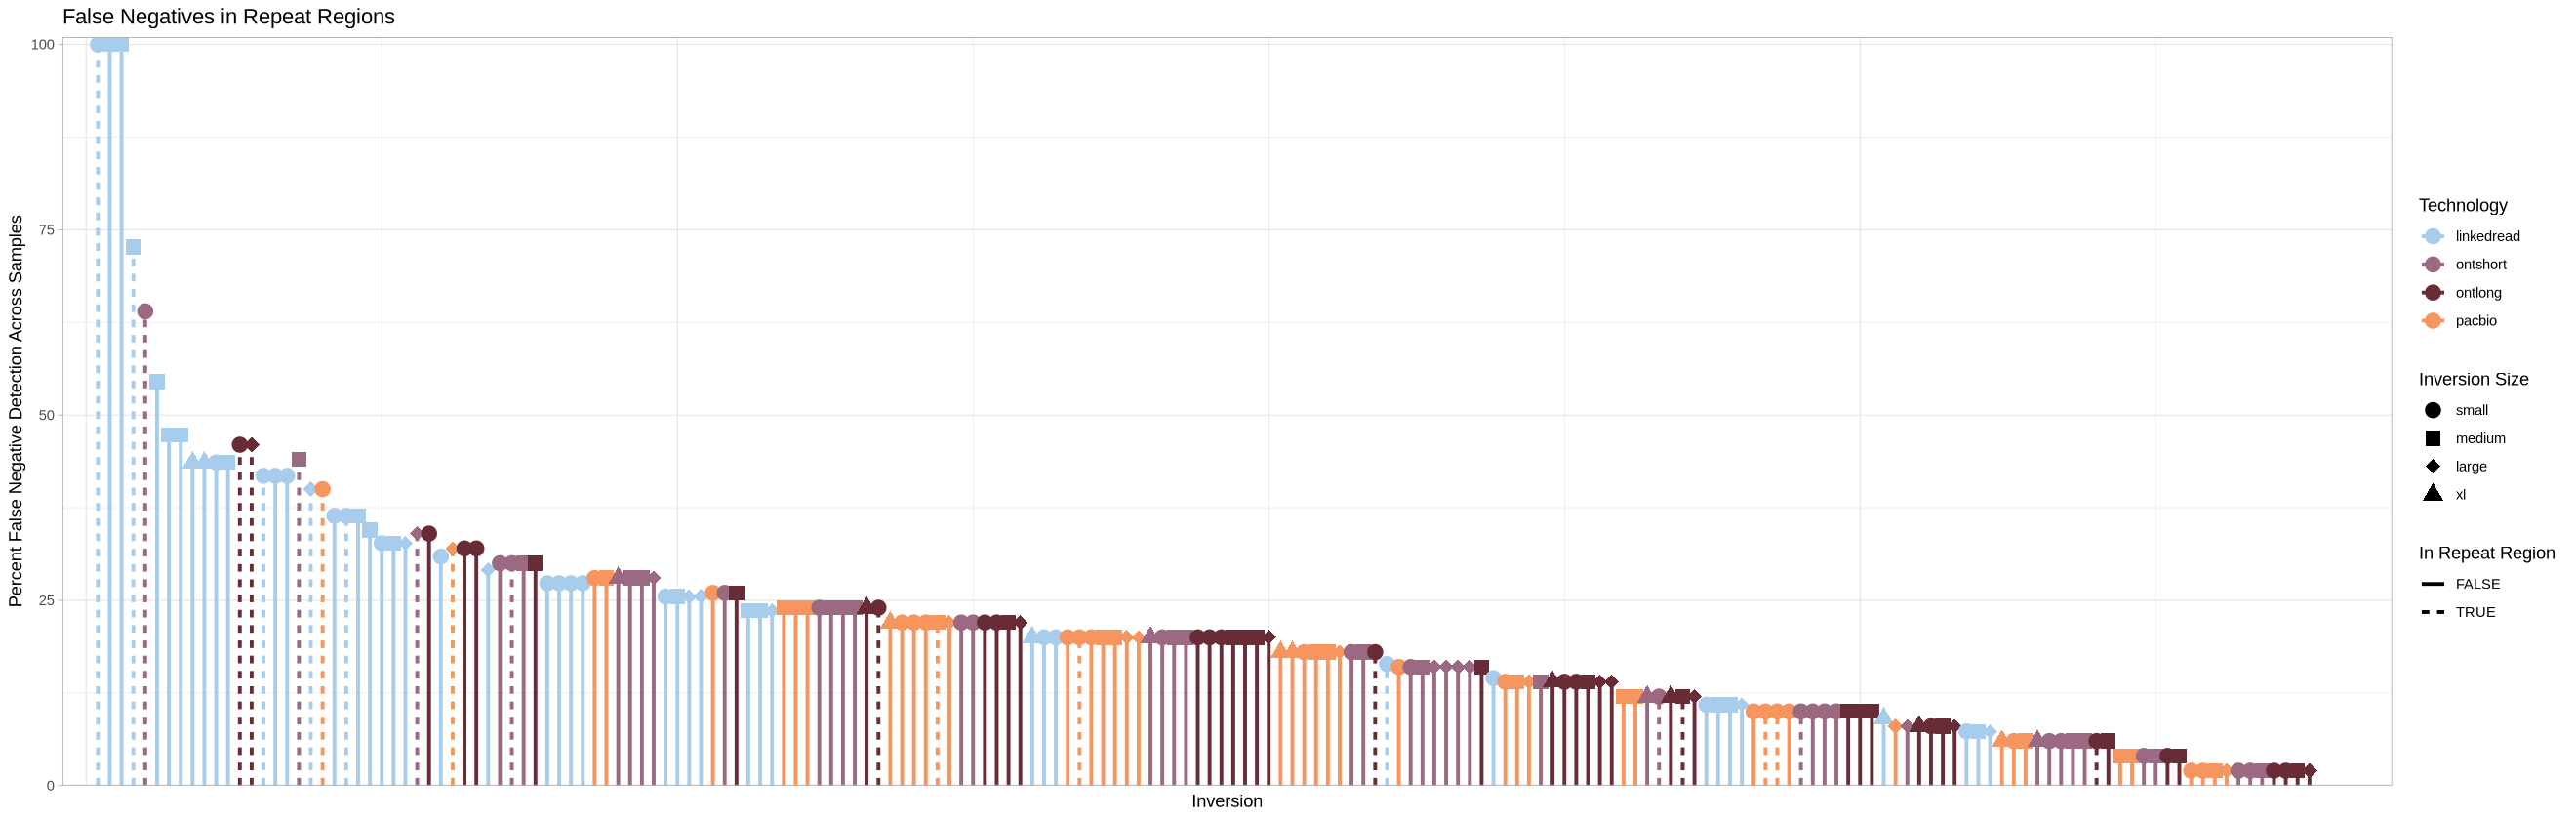

In [84]:
options(repr.plot.width = 22, repr.plot.height = 7)
ggplot(false_neg_all, aes(x = seq_id, y = 0, yend = perc, shape = size, color = platform)) +
    geom_point(size = 4, aes(y = perc)) +
    geom_segment(aes(linetype = is_repeat), linewidth = 1.1) +
    theme_light() +
    scale_shape_manual(values = c(19,15,18,17)) +
    scale_color_manual(values = tech_colors) +
    coord_cartesian(xlim = c(-2, 195), ylim = c(0, 101),expand = F) +
    labs(
        title = "False Negatives in Repeat Regions",
        color = "Technology",
        shape = "Inversion Size",
        linetype = "In Repeat Region"
    ) +
    theme(
        axis.text.x=element_blank(),
        axis.ticks.x=element_blank()
    ) +
    xlab("Inversion") +
    ylab("Percent False Negative Detection Across Samples")

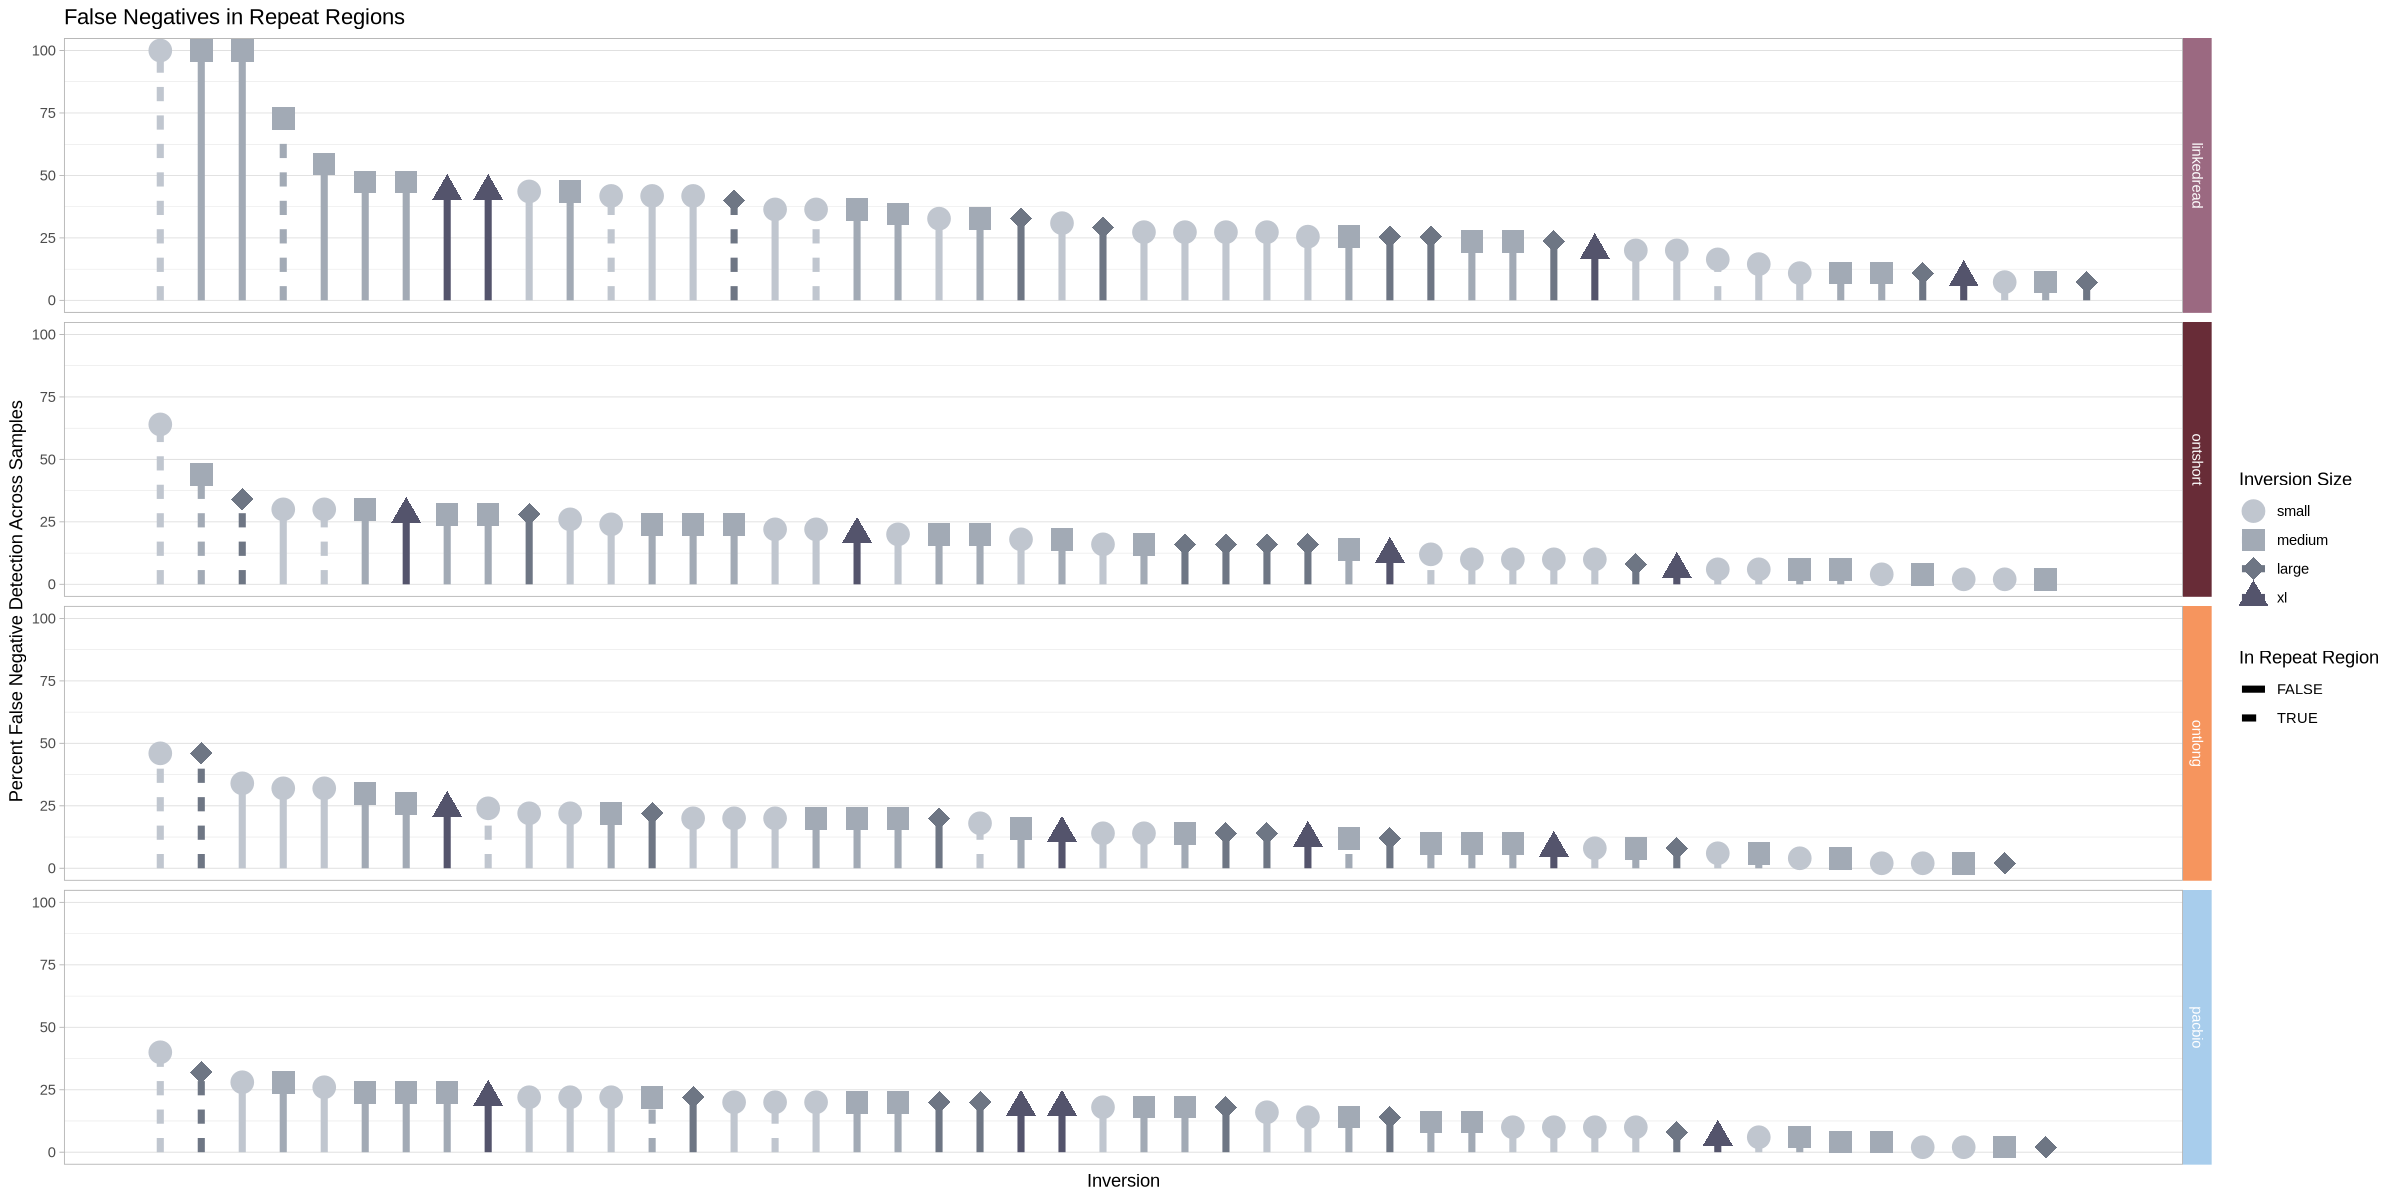

In [79]:
options(repr.plot.width = 20, repr.plot.height = 10)
.strip <- strip_themed(background_y = elem_list_rect(fill = tech_colors))

false_neg_all %>% group_by(platform) %>% 
    mutate(mx = max(perc)) %>% 
    arrange(desc(mx), .by_group = T) %>% 
    mutate(id = 1:length(perc)) %>%
    ggplot(aes(x = id, y = 0, yend = perc, shape = size, color = size)) +
        geom_point(size = 6, aes(y = perc)) +
        geom_segment(aes(linetype = is_repeat), linewidth = 2) +
        theme_light() +
        scale_shape_manual(values = c(19,15,18,17)) +
        scale_color_manual(values = size_colors) +
        labs(
            title = "False Negatives in Repeat Regions",
            color = "Inversion Size",
            shape = "Inversion Size",
            linetype = "In Repeat Region"
        ) +
        theme(
            axis.text.x=element_blank(),
            axis.ticks.x=element_blank(),
            panel.grid.major.x=element_blank(),
            panel.grid.minor.x=element_blank()
        ) +
        xlab("Inversion") +
        ylab("Percent False Negative Detection Across Samples") +
        facet_grid2(rows = vars(platform), strip = .strip)

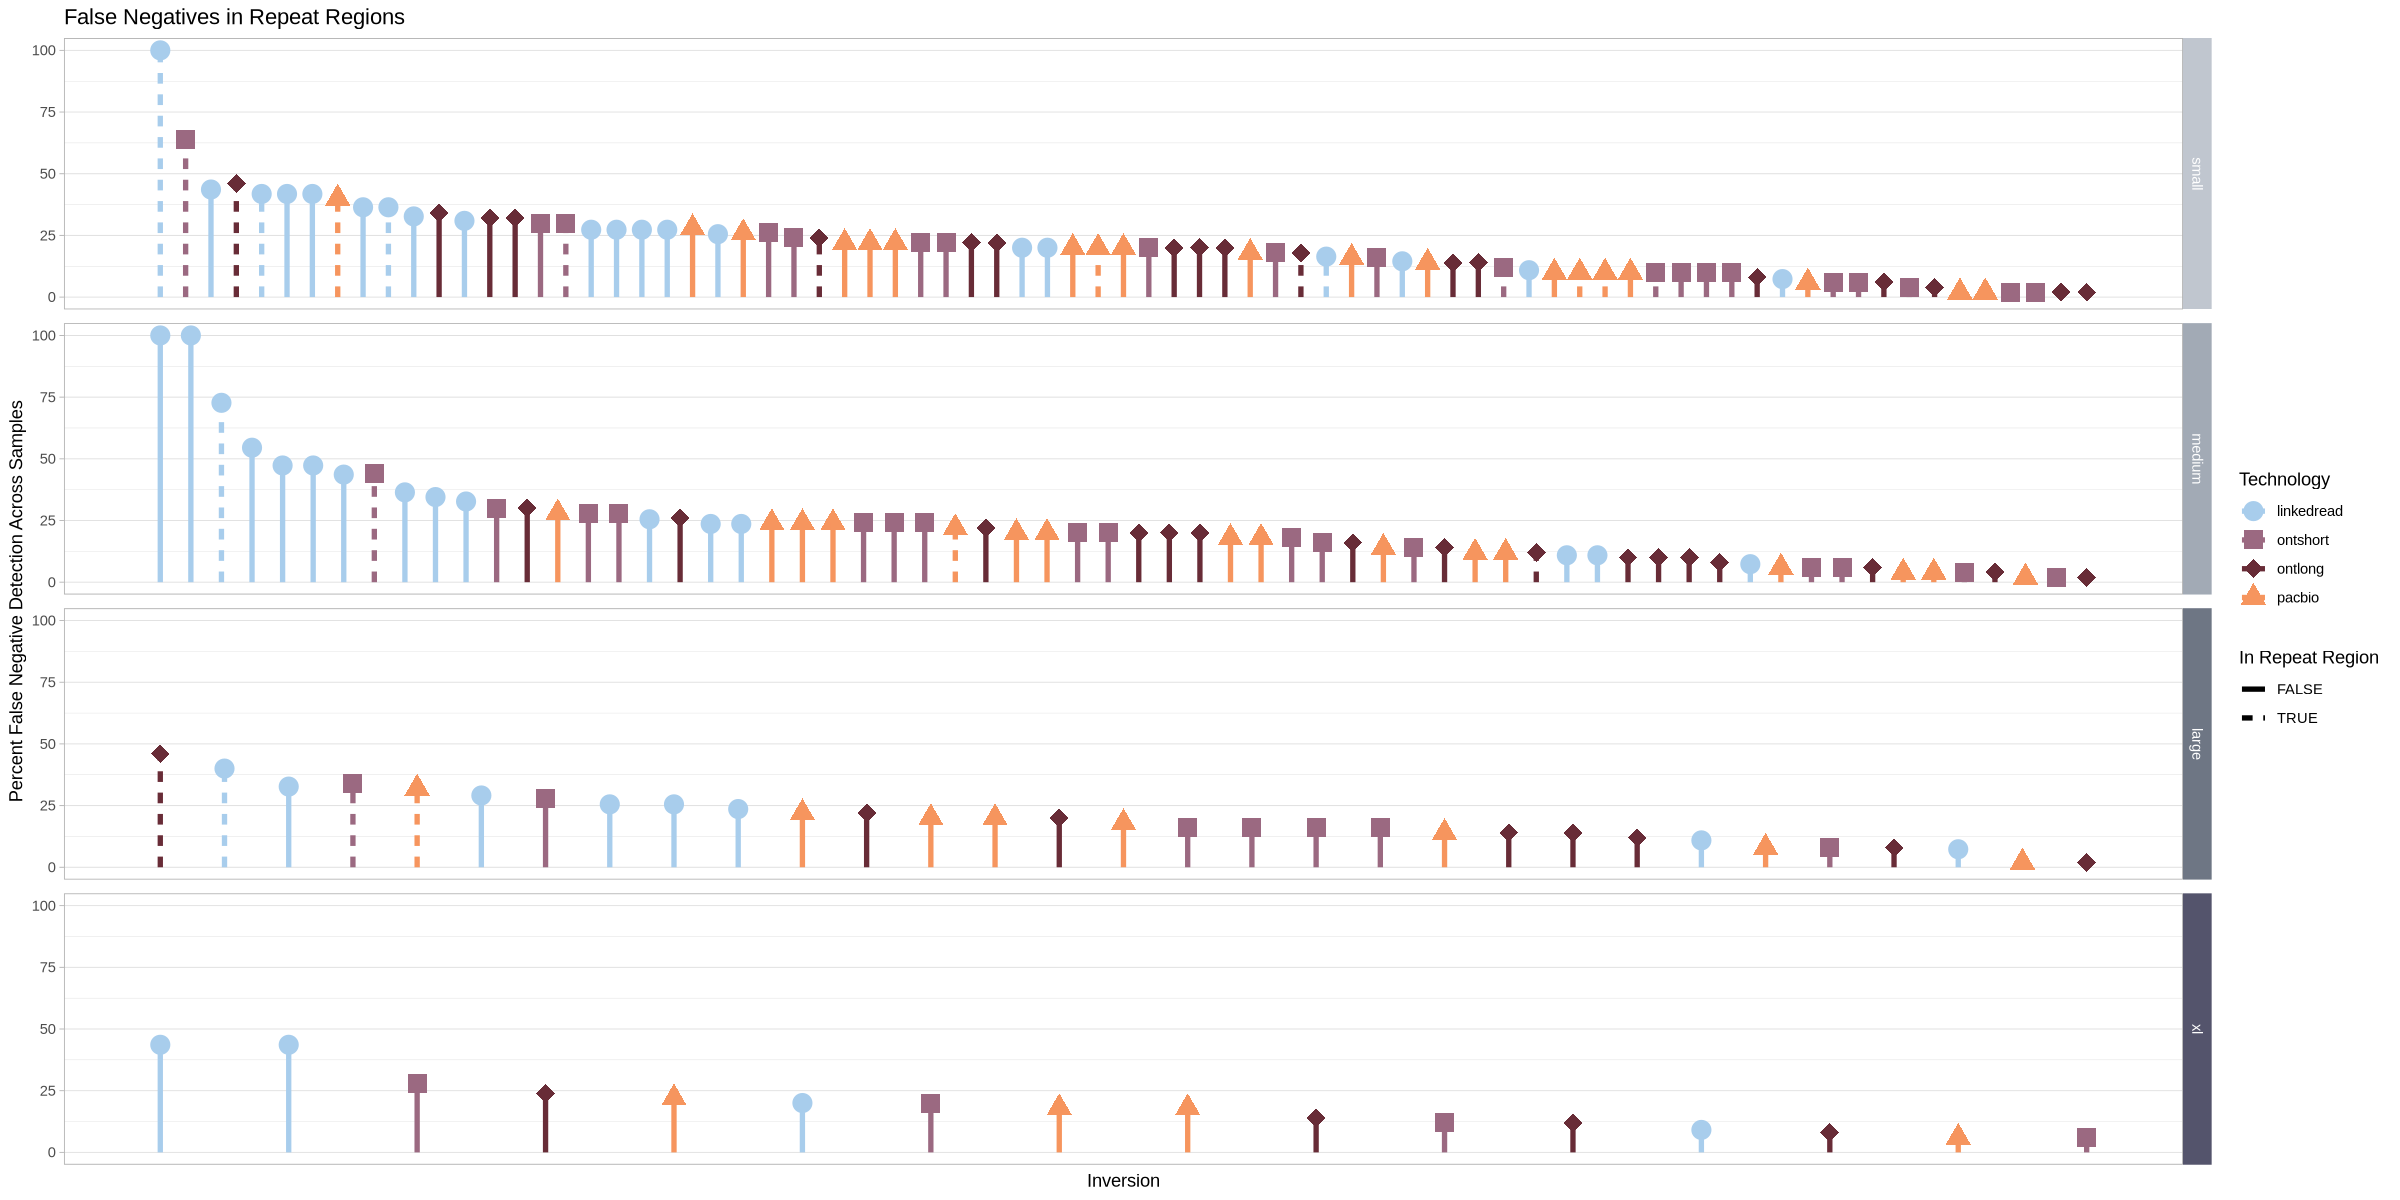

In [78]:
options(repr.plot.width = 20, repr.plot.height = 10)
.strip <- strip_themed(background_y = elem_list_rect(fill = size_colors))

false_neg_all %>% group_by(size) %>% 
    mutate(mx = max(perc)) %>% 
    arrange(desc(mx), .by_group = T) %>% 
    mutate(id = 1:length(perc)) %>%
    ggplot(aes(x = id, y = 0, yend = perc, shape = platform, color = platform)) +
        geom_point(size = 5, aes(y = perc)) +
        geom_segment(aes(linetype = is_repeat), linewidth = 1.5) +
        theme_light() +
        scale_shape_manual(values = c(19,15,18,17)) +
        scale_color_manual(values = tech_colors) +
        labs(
            title = "False Negatives in Repeat Regions",
            color = "Technology",
            shape = "Technology",
            linetype = "In Repeat Region"
        ) +
        theme(
            axis.text.x=element_blank(),
            axis.ticks.x=element_blank(),
            panel.grid.major.x=element_blank(),
            panel.grid.minor.x=element_blank()
        ) +
        xlab("Inversion") +
        ylab("Percent False Negative Detection Across Samples") +
        facet_grid2(rows = vars(size), scales = "free_x", independent = "x", strip = .strip)

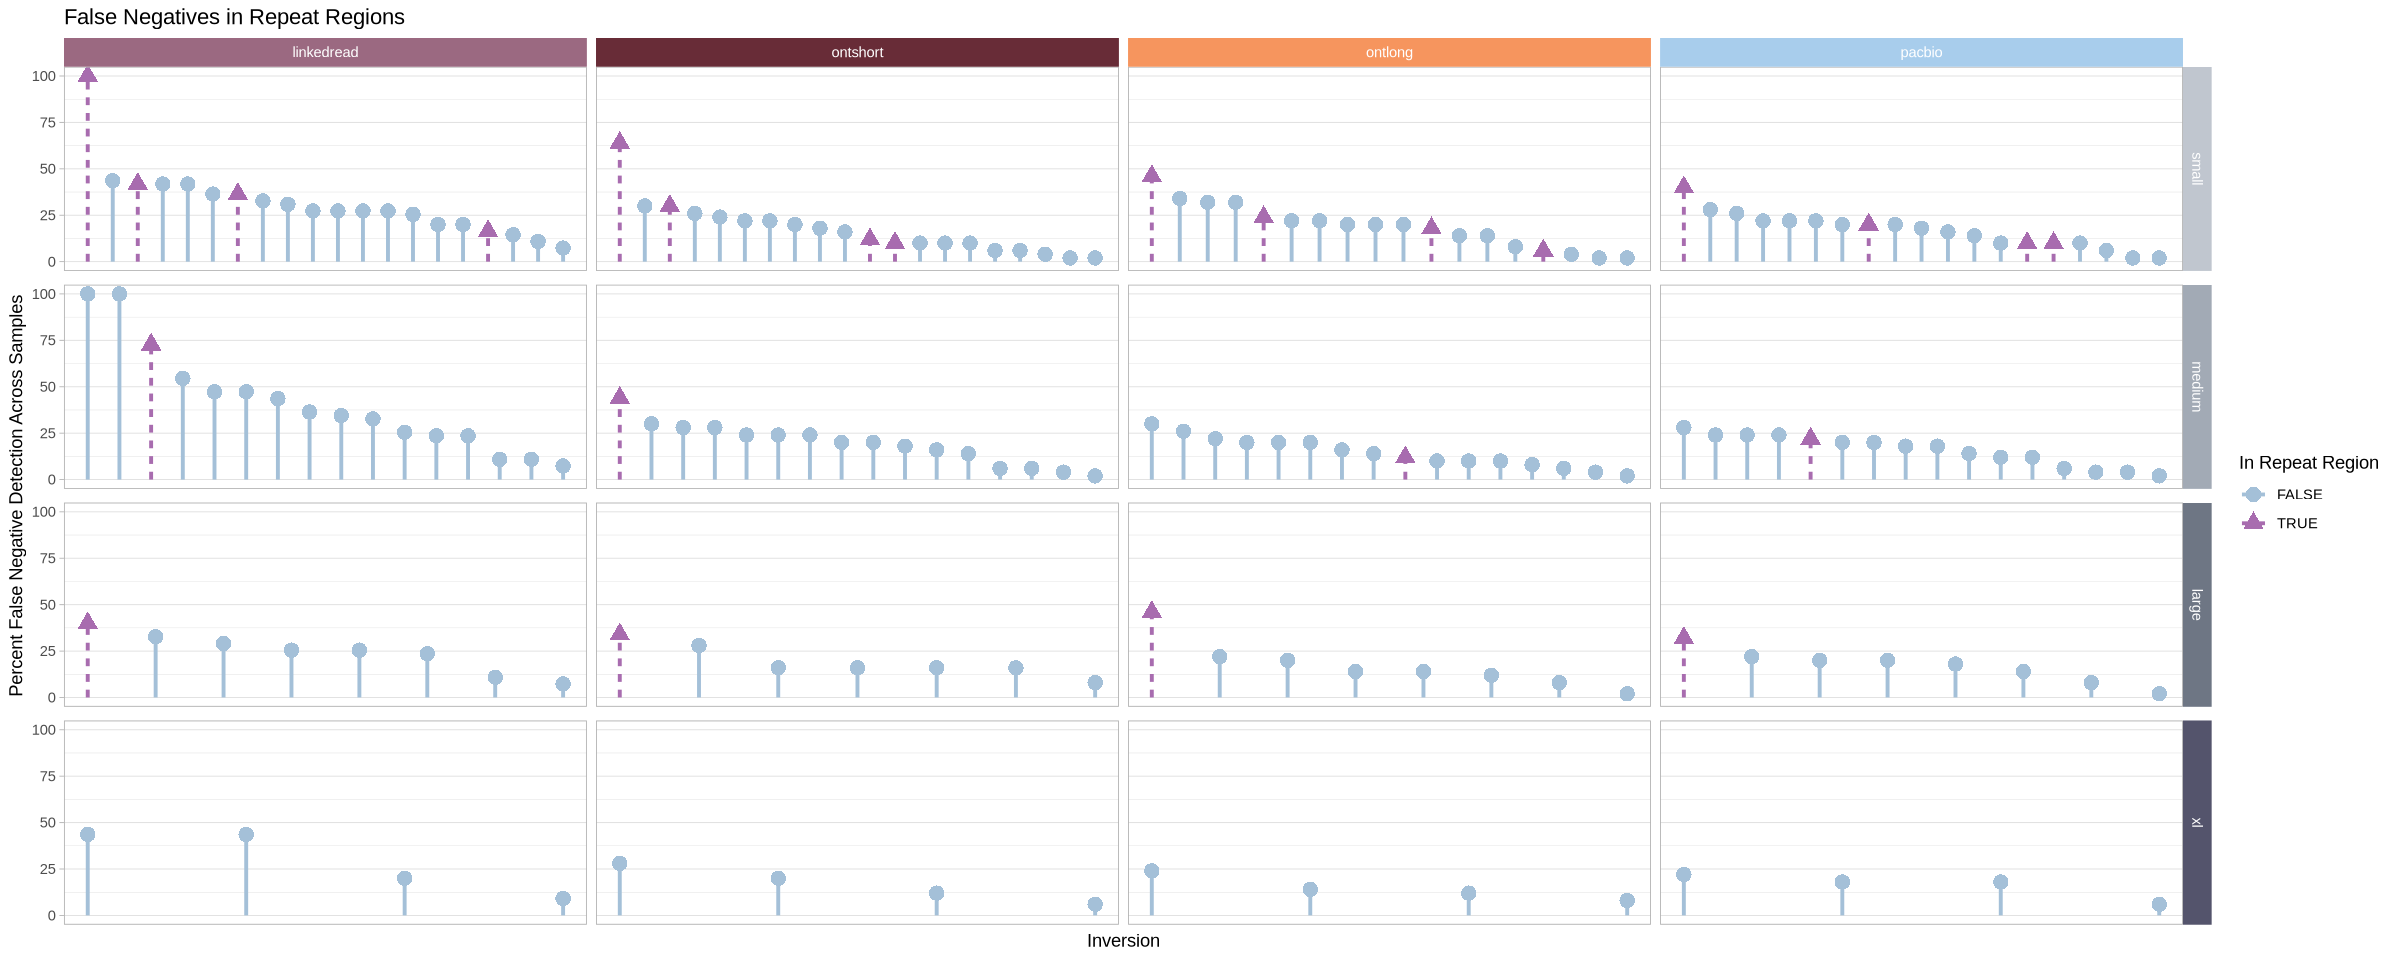

In [ ]:
freq_colors <- c(
    "#a4c0d8ff",
    "#a86cafff"
)
options(repr.plot.width = 20, repr.plot.height = 8)
.strip <- strip_themed(background_x = elem_list_rect(fill = tech_colors), background_y = elem_list_rect(fill = size_colors))

false_neg_all %>% group_by(platform, size) %>% 
    mutate(mx = max(perc)) %>% 
    arrange(desc(mx), .by_group = T) %>% 
    mutate(id = 1:length(perc)) %>%
    ggplot(aes(x = id, y = 0, yend = perc, shape = is_repeat, color = is_repeat)) +
        geom_point(size = 4, aes(y = perc)) +
        geom_segment(aes(linetype = is_repeat), linewidth = 1.1) +
        theme_light() +
        #scale_shape_manual(values = c(19,15,18,17)) +
        scale_color_manual(values = freq_colors) +
        labs(
            title = "False Negatives in Repeat Regions",
            color = "In Repeat Region",
            shape = "In Repeat Region",
            linetype = "In Repeat Region"
        ) +
        theme(
            axis.text.x=element_blank(),
            axis.ticks.x=element_blank(),
            panel.grid.major.x=element_blank(),
            panel.grid.minor.x=element_blank()
        ) +
        xlab("Inversion") +
        ylab("Percent False Negative Detection Across Samples") +
        facet_grid2(rows = vars(size), cols = vars(platform), scales = "free_x", independent = "x", strip = .strip)